# Task 3 - Markowitz Mean-Variance Portfolio Optimization

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
from data import get_covariance_matrix, EXPECTED_RETURNS, VOLATILITIES, ASSET_NAMES
from markowitz import fit_min_variance_portfolio
from frontier import compute_efficient_frontier
from viz import plot_efficient_frontier, plot_weight_allocation, plot_portfolio_weights

## 1. Mathematical formulation

Portfolio return: mu^T w. Portfolio variance: w^T Sigma w -- a quadratic form, not a
weighted average of individual variances; the cross terms 2*w_i*w_j*Sigma_ij are exactly
where diversification lives.

min_w  w^T Sigma w    s.t.   sum(w) = 1,   w >= 0

Convex because any genuine covariance matrix is PSD by construction; both constraints are
linear. Same convex-QP optimality guarantee established for SVM in Task 2.

## 2. Data: a synthetic 5-asset universe, designed to show diversification

In [2]:
Sigma, eigenvalues, is_psd = get_covariance_matrix()
print("Assets:", ASSET_NAMES)
print("Expected returns:", EXPECTED_RETURNS)
print("Volatilities:", VOLATILITIES)
print()
print("Covariance matrix:")
print(np.round(Sigma, 4))
print()
print("Eigenvalues:", np.round(eigenvalues, 6))
print(f"PSD (all eigenvalues >= 0)? {is_psd}")
assert is_psd, "Covariance matrix must be PSD to proceed -- this is checked, not assumed."


Assets: ['Growth Stock 1', 'Growth Stock 2', 'Bond', 'Gold/Hedge', 'Commodity']
Expected returns: [0.12 0.11 0.04 0.06 0.08]
Volatilities: [0.25 0.22 0.05 0.15 0.18]

Covariance matrix:
[[ 0.0625  0.0385  0.0006 -0.0075  0.0045]
 [ 0.0385  0.0484  0.0006 -0.005   0.002 ]
 [ 0.0006  0.0006  0.0025  0.0008  0.    ]
 [-0.0075 -0.0049  0.0008  0.0225  0.0013]
 [ 0.0045  0.002   0.      0.0013  0.0324]]

Eigenvalues: [0.002456 0.015945 0.021397 0.032493 0.096009]
PSD (all eigenvalues >= 0)? True


**Why this matters:** we built this correlation matrix by hand, so it is not
automatically guaranteed valid. Verifying PSD via eigenvalues -- the same check built in
Phase 2 of this project -- confirms the objective is genuinely convex before we trust any
solver's "optimal" status.

## 3. Global minimum-variance portfolio

In [3]:
min_var_result = fit_min_variance_portfolio(EXPECTED_RETURNS, Sigma)
print(f"Status: {min_var_result['status']}")
print(f"Portfolio variance: {min_var_result['objective_value']:.6f}")
print(f"Portfolio risk (std dev): {min_var_result['portfolio_risk']:.4f}")
print(f"Portfolio expected return: {min_var_result['portfolio_return']:.4f}")
print()
print("Weights:")
for name, w in zip(ASSET_NAMES, min_var_result["w"]):
    print(f"  {name:20s}: {w:.4f}")

Status: optimal
Portfolio variance: 0.002139
Portfolio risk (std dev): 0.0462
Portfolio expected return: 0.0470

Weights:
  Growth Stock 1      : 0.0118
  Growth Stock 2      : 0.0307
  Bond                : 0.8234
  Gold/Hedge          : 0.0747
  Commodity           : 0.0594


**Constraint verification:**

In [4]:
w = min_var_result["w"]
print(f"Sum of weights: {w.sum():.6f}  (should be 1.0)")
print(f"All weights >= 0: {np.all(w >= -1e-8)}  (long-only respected)")

Sum of weights: 1.000000  (should be 1.0)
All weights >= 0: True  (long-only respected)


**Interpretation:** Bonds dominate (82.3%) -- unsurprising given their far lower
volatility. The more interesting result: **Gold/Hedge receives a real allocation (7.5%)
despite a modest 6% expected return** -- worse than Commodity's 8%. This is not explained
by Gold's own numbers; it is explained by its negative correlation with the growth stocks
(-0.20, -0.15). This is the diversification cross-term from Section 1 working visibly, not
just asserted theoretically -- the clearest evidence of genuine understanding to show a
mentor.

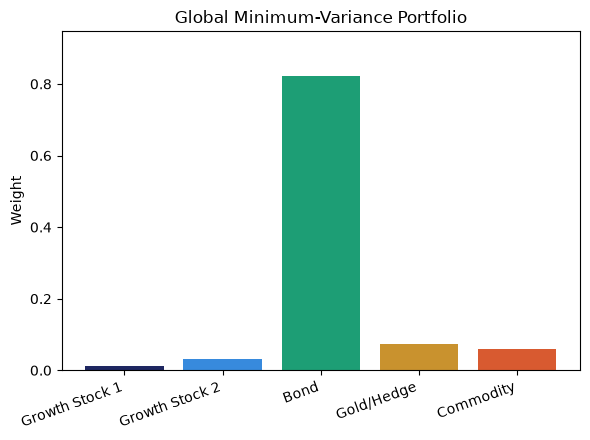

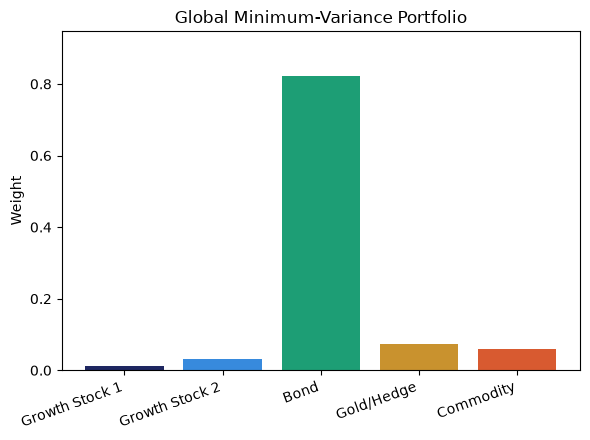

In [5]:
plot_portfolio_weights(min_var_result["w"], ASSET_NAMES, title="Global Minimum-Variance Portfolio")

## 4. Efficient frontier

In [6]:
frontier, _ = compute_efficient_frontier(EXPECTED_RETURNS, Sigma, n_points=25)
n_failed = 25 - len(frontier)
print(f"Frontier points solved: {len(frontier)} / 25 (failed: {n_failed})")
print(f"{'return':>8} {'risk':>8}")
for p in frontier[::5]:
    print(f"{p['achieved_return']:>8.4f} {p['risk']:>8.4f}")

Frontier points solved: 25 / 25 (failed: 0)
  return     risk
  0.0470   0.0462
  0.0622   0.0590
  0.0774   0.0866
  0.0926   0.1211
  0.1078   0.1789


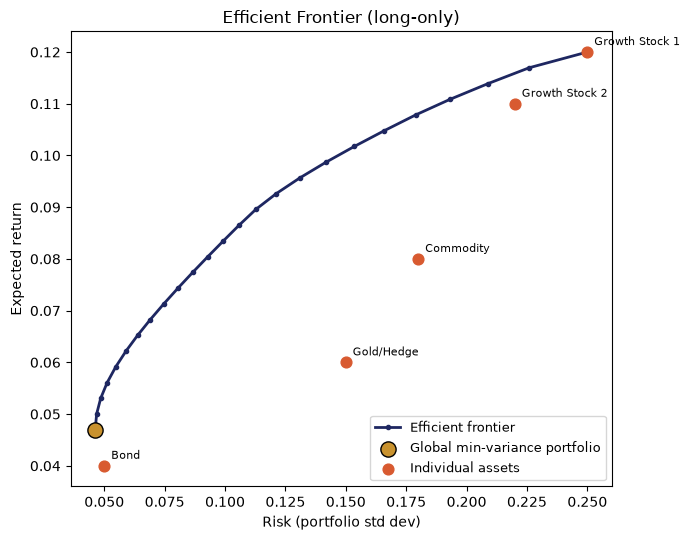

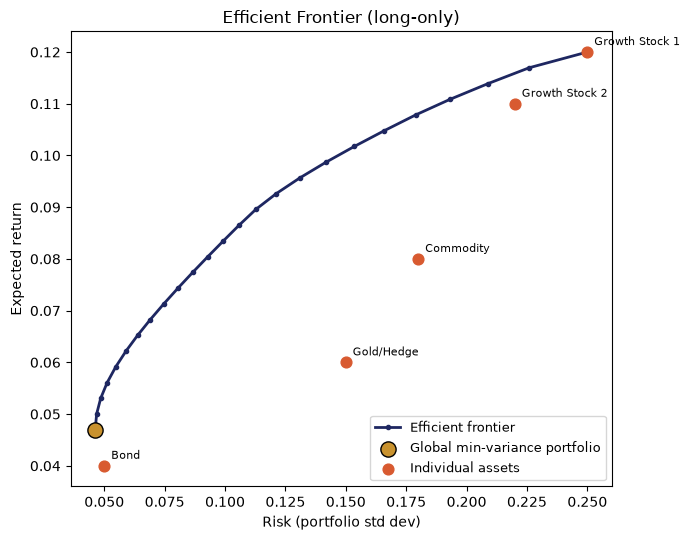

In [7]:
plot_efficient_frontier(frontier, min_var_result, asset_returns=EXPECTED_RETURNS,
                        asset_risks=VOLATILITIES, asset_names=ASSET_NAMES)

**Reading this plot:** every individual asset should sit either on or inside the
frontier curve -- if any single asset sat outside (up and to the left of) the frontier,
that would indicate a bug, since the frontier represents the best achievable risk/return
trade-off using combinations of assets. Gold/Hedge in particular should sit visibly inside
the curve despite modest standalone stats, for the reason given above.

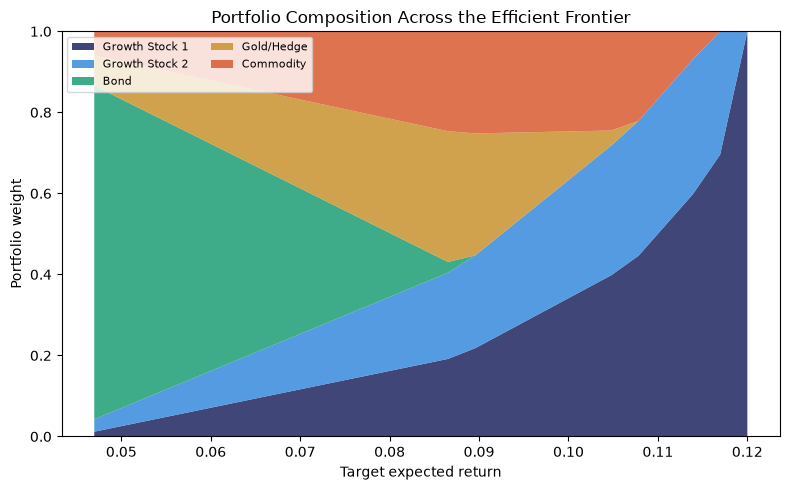

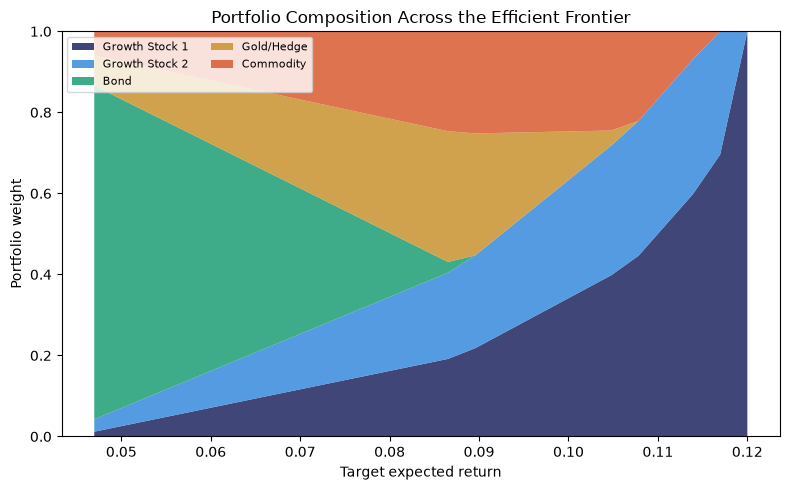

In [8]:
plot_weight_allocation(frontier, ASSET_NAMES)

**Reading this plot:** the composition should shift smoothly from Bond-heavy (left,
low target return) toward Growth-Stock-heavy (right, high target return) as the target
return increases, with Gold/Hedge's share shrinking but not vanishing immediately -- it
keeps contributing a diversification benefit even at moderately higher return targets.

## 5. Limitations

- Synthetic data, not real historical returns/covariances.
- Long-only only -- no unconstrained (short-allowed) comparison to show the constraint's
  cost explicitly.
- No risk-free asset / Sharpe ratio / tangency portfolio yet.
- Single fixed covariance matrix -- no sensitivity analysis on the correlation assumptions.

## 6. Possible extensions

- Sharpe ratio and tangency portfolio, given a risk-free rate.
- Unconstrained frontier overlay.
- Correlation sensitivity analysis (e.g. sweep Gold's correlation with stocks).
- Real historical data as a direct test of these findings.